# ISO 20414:2020 — Test 8: Exit route allocation

Corridor with rooms (ISO 20414:2020 Table 9 / Figure 5). 13 agents, pre-evacuation time 0 — Figure 5 places 1 person in each of rooms 1, 2, 4, 5, 6, 7–12 and 2 in room 3 (11 x 1 + 1 x 2 = 13); Table 9's accompanying text says "23 agents", which is inconsistent with its own figure, so this scenario follows the figure. Occupants in rooms 1,2,3,4,7,8,9,10 are allocated to the main exit; the rest to the secondary exit. Each agent must reach its allocated exit.

In [1]:
from datetime import datetime

print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 30 May 2026, 20:47 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pedpy
from jupedsim_scenarios import load_scenario, run_scenario
from shapely.geometry import Point, Polygon

In [3]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
        "figure.figsize": (8, 5),
    }
)

## Load the scenario and the encoded route allocation

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-08-route-allocation.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())
raw = scenario.raw
if "journeys" in raw:
    journey_map = {j["stages"][0]: j["stages"][-1] for j in raw["journeys"]}
else:
    j_to_exit = {j["id"]: j["sequence"][-1] for j in raw.get("journeys_v2", [])}
    journey_map = {
        did: j_to_exit.get((d.get("journey_weights") or [{}])[0].get("journey_id"), "")
        for did, d in scenario.distributions.items()
    }
print("expected assignment:", journey_map)

Scenario: /work/standards/iso/scenario_files/Iso-08-route-allocation.zip
  Model:         CollisionFreeSpeedModel
  Seed:          420
  Max time:      300s
  Exits:         2
  Distributions: 12
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~13
    jps-distributions_0: 1 agents
    jps-distributions_1: 1 agents
    jps-distributions_2: 1 agents
    jps-distributions_3: 1 agents
    jps-distributions_4: 1 agents
    jps-distributions_5: 1 agents
    jps-distributions_6: 1 agents
    jps-distributions_7: 2 agents
    jps-distributions_8: 1 agents
    jps-distributions_9: 1 agents
    jps-distributions_10: 1 agents
    jps-distributions_11: 1 agents
expected assignment: {'jps-distributions_0': 'jps-exits_0', 'jps-distributions_1': 'jps-exits_0', 'jps-distributions_2': 'jps-exits_0', 'jps-distributions_3': 'jps-exits_0', 'jps-distributions_4': 'jps-exits_0', 'jps-distributions_5': 'jps-exits_0', 'jps-distributions_6': 'jps-exits_0', 'jps-distributions_7': 'jps-

## Helper functions

In [5]:
def agent_to_distribution(trajectory, distributions):
    first = trajectory.data.sort_values(["id", "frame"]).groupby("id").first().reset_index()
    polys = {k: Polygon(v["coordinates"]) for k, v in distributions.items()}
    mapping = {}
    for row in first.itertuples():
        point = Point(row.x, row.y)
        for did, poly in polys.items():
            if poly.covers(point):
                mapping[row.id] = did
                break
    return mapping


def agent_to_actual_exit(trajectory, exits):
    last = trajectory.data.sort_values(["id", "frame"]).groupby("id").last().reset_index()
    polys = {k: Polygon(v["coordinates"]) for k, v in exits.items()}
    return {
        row.id: min(polys, key=lambda eid: polys[eid].distance(Point(row.x, row.y)))
        for row in last.itertuples()
    }

## Run and map expected vs actual exit

In [6]:
result = run_scenario(scenario, seed=42)
trajectory = pedpy.TrajectoryData(
    result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(), frame_rate=result.frame_rate
)
homes = agent_to_distribution(trajectory, scenario.distributions)
actuals = agent_to_actual_exit(trajectory, scenario.exits)
assignment = pd.DataFrame(
    [
        {
            "agent": int(aid),
            "home": homes.get(aid),
            "expected_exit": journey_map.get(homes.get(aid)),
            "actual_exit": actuals[aid],
        }
        for aid in actuals
    ]
)
assignment["matches"] = assignment["expected_exit"] == assignment["actual_exit"]
assignment

,agent,home,expected_exit,actual_exit,matches
0,613,jps-distributions_0,jps-exits_0,jps-exits_0,True
1,614,jps-distributions_1,jps-exits_0,jps-exits_0,True
2,615,jps-distributions_2,jps-exits_0,jps-exits_0,True
3,616,jps-distributions_3,jps-exits_0,jps-exits_0,True
4,617,jps-distributions_4,jps-exits_0,jps-exits_0,True
5,618,jps-distributions_5,jps-exits_0,jps-exits_0,True
6,619,jps-distributions_6,jps-exits_0,jps-exits_0,True
7,620,jps-distributions_7,jps-exits_0,jps-exits_0,True
8,621,jps-distributions_7,jps-exits_0,jps-exits_0,True
9,622,jps-distributions_8,jps-exits_1,jps-exits_1,True


## Plot trajectories coloured by allocated exit

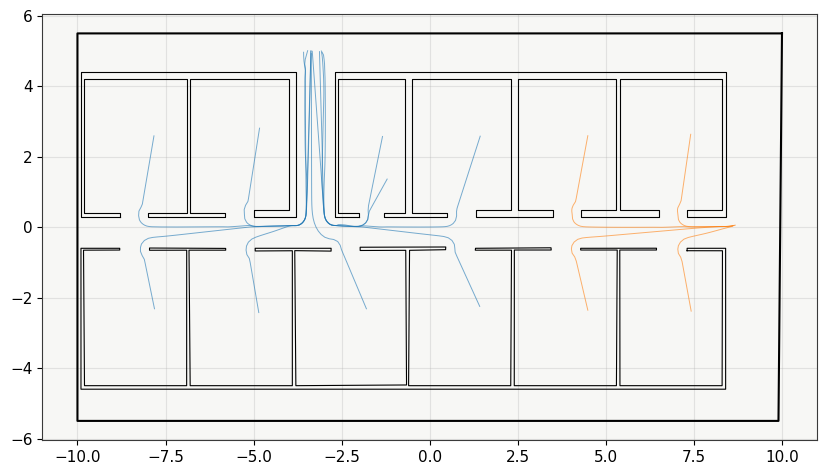

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
x, y = scenario.walkable_polygon.exterior.xy
ax.plot(x, y, "k-")
for interior in scenario.walkable_polygon.interiors:
    ix, iy = interior.xy
    ax.plot(ix, iy, "k-", lw=0.8)
colors = {"jps-exits_0": "tab:blue", "jps-exits_1": "tab:orange"}
for agent_id, sub in trajectory.data.sort_values("frame").groupby("id"):
    row = assignment[assignment.agent == agent_id]
    if len(row) == 0:
        continue
    ax.plot(sub.x, sub.y, color=colors.get(row.iloc[0].expected_exit, "k"), alpha=0.6, lw=0.7)
ax.set_aspect("equal")
plt.show()

## Acceptance

In [8]:
match_rate = assignment["matches"].mean()
print(f"allocation match rate: {match_rate:.1%}")
assert match_rate == 1.0, assignment[~assignment["matches"]]
result.cleanup()

allocation match rate: 100.0%
